# **ANALYSE**<br> _RECONNAISSANCE ET FRANCHISES DES CATNAT_

Les données utilisées ont été scrappées du site : https://www.ccr.fr/portail-catastrophes-naturelles/liste-arretes/

## __IMPORTS__

In [1]:
# Installations
! uv pip install seaborn morethemes pyfonts pypalettes drawarrow dayplot contextily geopandas

Using Python 3.13.9 environment at: C:\Users\Asus\Documents\14_PrixChangementClimatique\.venv
Resolved 41 packages in 480ms
Prepared 2 packages in 107ms
Installed 14 packages in 200ms
 + affine==2.4.0
 + cligj==0.7.2
 + contextily==1.7.0
 + dayplot==0.5.1
 + drawarrow==0.1.0
 + geographiclib==2.1
 + geopy==2.4.1
 + mercantile==1.2.1
 + morethemes==0.5.1
 + narwhals==2.16.0
 + pyfonts==1.2.0
 + pypalettes==0.2.1
 + rasterio==1.5.0
 + seaborn==0.13.2


In [47]:
import duckdb

# The usual suspects
import numpy as np
import pandas as pd

# Chart and Figure
import seaborn as sns
import matplotlib
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# Fonts, Palettes, Themes, Arrow (https://github.com/y-sunflower)
# Strong inspiration: https://www.yan-holtz.com/
import morethemes as mt
from pyfonts import load_google_font, load_font
from pypalettes import load_palette, load_cmap
from drawarrow import fig_arrow
import dayplot as dp # Calendar plot for timeseries

# GeoSpatial
import contextily as ctx
from shapely.affinity import translate, scale
import geopandas as gpd

# Removing warnings
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Setup
font = load_google_font("Montserrat", italic=False) # check here: https://fonts.google.com/
mt.set_theme("nature") # Main color for text is not black, but cool layout

source_text = "Source: CCR (Caisse Centrale de Réassurance)" # Main Source for the analysis

## __LOAD DATA__

In [4]:
PCC_DUCKDB_FILE = "dev.duckdb"
con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)

In [6]:
query_ccr_main = """
SELECT
	*
FROM dev.main.ccr_main_page
"""

ccr_main = con.sql(query_ccr_main)
ccr_main_df = ccr_main.df()
ccr_main_df.head(2)

,codePeril,nomPeril,dateArrete,dateParutionJO,codeNOR,codeInseePole,codeArrete
0,None,"Inondations et/ou Coulées de Boue, Inondations...",2026-01-19,2026-01-24,INTE2601369A,None,904
1,None,Sécheresse,2025-12-12,2025-12-13,INTE2534330A,None,903


In [7]:
query_ccr_details = """
SELECT
	*
FROM dev.main.ccr_details
"""

ccr_details = con.sql(query_ccr_details)
ccr_details_df = ccr_details.df()
ccr_details_df.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


In [50]:
# For Geospatial Analysis
dept_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-avec-outre-mer.geojson"
communes_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson"

dept_geo = gpd.read_file(dept_geojson_url)
communes_geo = gpd.read_file(communes_geojson_url)

## __CHART & FIGURES__

### _GLOBAL CATNAT EVOLUTION_

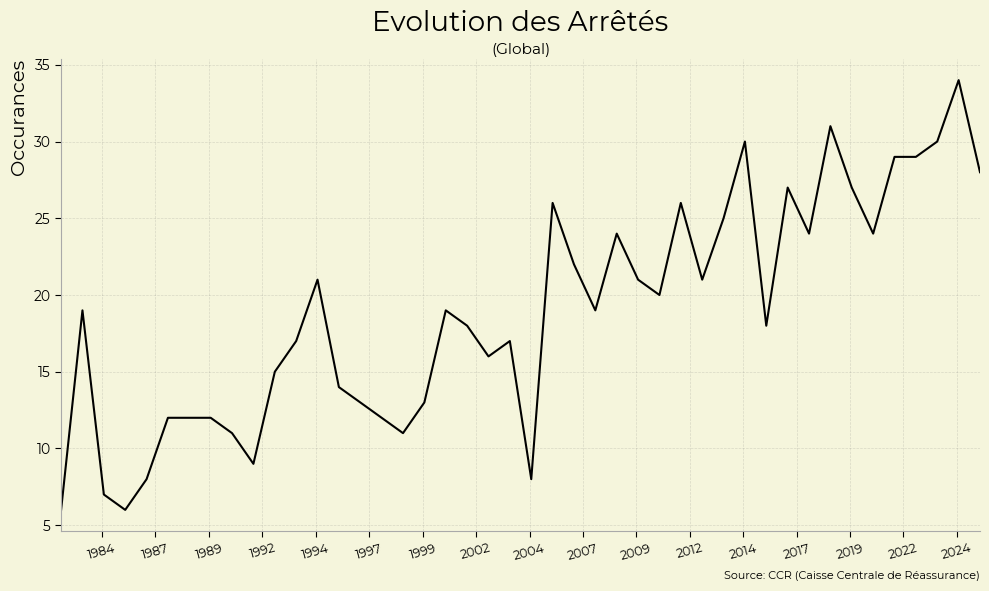

In [49]:
def global_evolution_catnat(df, 
                            font=None,
                            resample="YE",
                            source_text=source_text,
                            figsize=(10, 6)):
    """
    Plot the global evolution of catnat over time.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing a column named "dateArrete" with dates of decrees.
    font : str or matplotlib.font_manager.FontProperties, optional
        Font to use for text elements in the plot. If None, uses the default font.
    resample : str, default="YE"
        Resampling frequency for the time series (e.g., "YE" for year-end, "M" for month-end).
    source_text : str, optional
        Text to display as the source of the data, typically at the bottom of the plot.
    figsize : tuple of int, default=(10, 6)
        Figure size in inches (width, height).

    Returns
    -------
    matplotlib.figure.Figure
        The generated figure object containing the plot.

    Notes
    -----
    - The "dateArrete" column in the DataFrame must be in the format "%d-%m-%Y".
    - The plot is limited to data up to the year 2025.
    - The x-axis is formatted according to the resampling frequency.
    """
    
    # Data Prep
    df_plot = df.copy()
    df_plot["dateArrete"] = pd.to_datetime(df_plot["dateArrete"], format="%d-%m-%Y")

    df_grouped = (
        df_plot.set_index("dateArrete")
        .resample(resample)
        .size()
        .reset_index(name="count")
        .set_index("dateArrete")
        .loc[:"2025"] # Limit to 2025 for visual purposes
    )

    # Plotting Time series
    fig, ax = plt.subplots(figsize=figsize)
    plt.plot(
        df_grouped.index,
        df_grouped["count"],
        linestyle="-",
        color="black",
    )

    # Title
    plt.title("Evolution des Arrêtés", 
              font=font, 
              fontsize=20, 
              color="black", 
              pad=20)

    # Subtitle
    plt.text(
        0.5,
        1.01,
        "(Global)",
        font=font,
        fontsize=11,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )
    plt.xlabel("")
    plt.ylabel("Occurances", font=font, fontsize=14, color="black")

    # Formatting x axis
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%"+resample[:-1]))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=30)) # by reducing this number you increase number of ticks

    # Axis ticks
    plt.xticks(font=font, rotation=15, fontsize=9)
    plt.yticks(font=font, fontsize=10)
    plt.xlim([df_grouped.index.min(), pd.to_datetime("2025-12-31")])

    # Source Info
    plt.text(
        1,
        -0.105,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    plt.tight_layout()
    return fig

global_evolution_catnat(df=ccr_main_df, font=font);

### _CALENDAR PLOT_

In [34]:
main_data_occur_total = ccr_main_df.groupby("dateArrete").size()

# All Inodations type are converted into Inondations
# Other péril are just Autre
ccr_main_df["nomPeril"] = (
    ccr_main_df["nomPeril"]
    .mask(ccr_main_df["nomPeril"].str.contains("Inondations"), "Inondations")
    .where(ccr_main_df["nomPeril"].str.contains("Inondations|Sécheresse"), "Autre")
)

main_data_occur_inond = ccr_main_df[ccr_main_df["nomPeril"] == "Inondations"].groupby("dateArrete").size()
main_data_occur_secheresse = ccr_main_df[ccr_main_df["nomPeril"] == "Sécheresse"].groupby("dateArrete").size()

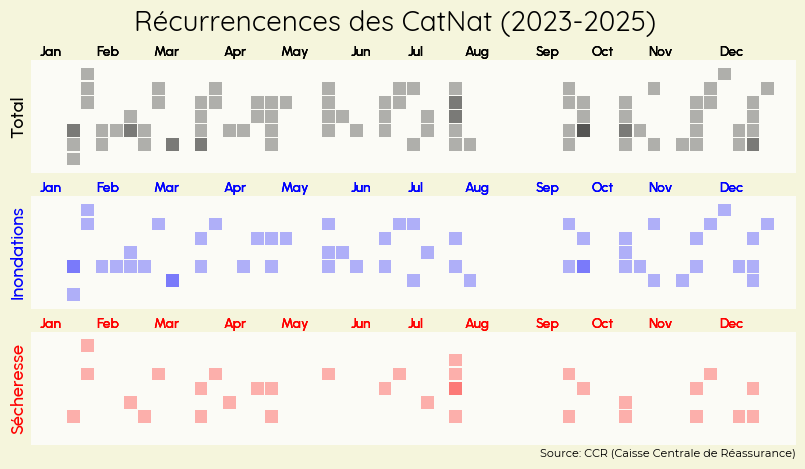

In [63]:
font_url = "https://github.com/coreyhu/Urbanist/blob/main/fonts/ttf"
fontyear = load_font(f"{font_url}/Urbanist-Medium.ttf?raw=true")

start_year = 2023 # Change start
end_year = 2025
years_to_plot = range(start_year, end_year + 1)

style_args = dict(
    day_kws={"alpha": 0}, # Hide day borders
    month_kws={"font": fontyear, "size": 10},
    month_y_margin=-8.5, # Month label position
    color_for_none="None", # None/Transparent background for stacking
    alpha=0.3
)

data = [main_data_occur_total, main_data_occur_inond, main_data_occur_secheresse]
titles = ["Total", "Inondations", "Sécheresse"]
colors_band = ["black", "blue", "red"] 
cmaps = [LinearSegmentedColormap.from_list("monochrome", [colors_band[0], colors_band[0]]),
         LinearSegmentedColormap.from_list("monochrome", [colors_band[1], colors_band[1]]),
         LinearSegmentedColormap.from_list("monochrome", [colors_band[2], colors_band[2]])]

# The idea her is overlay calendars, 
# colored box will then overlay and increase in color intesity by stacking
fig, axs = plt.subplots(nrows=3, figsize=(15, 5))

for i, (df_cal, color, title) in enumerate(zip(data, colors_band, titles)):
    for _, year in enumerate(years_to_plot):
        subset = df_cal[df_cal.index.year == year].copy()

        if subset.empty: continue # No péril of that type during this specific year

        try:
            delta_years = end_year - year
            subset.index = subset.index + pd.offsets.DateOffset(years=delta_years)
        except ValueError:
            subset = subset[~((subset.index.month == 2) & (subset.index.day == 29))] # For Febraury
            subset.index = subset.index.map(lambda d: d.replace(year=end_year))

        # Modifying color of calendar layers
        layer_style = style_args.copy()
        layer_style['cmap'] = cmaps[i]
        layer_style['month_kws']["color"] = color

        dp.calendar(
            subset.index,
            subset.values,
            start_date=f"{end_year}-01-01",
            end_date=f"{end_year}-12-31",
            ax=axs[i],
            **layer_style
        )

    axs[i].text(
        x=-2, y=3.5, 
        s=title, 
        size=13, rotation=90, 
        color=color, 
        va="center", font=fontyear
    )

    axs[i].set_facecolor("#FBFBF6") # You can change this, it is to match with "nature" theme

plt.suptitle(f"Récurrencences des CatNat ({start_year}-2025)", fontsize=20, color="black")

plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=axs[-1].transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

plt.show()

### _BAR CHART LIBELLE AVIS_

In [43]:
# Modifying details data
ccr_details_df["dateArrete"] = pd.to_datetime(ccr_details_df["dateArrete"])
ccr_details_df["libelleAvis"] = ccr_details_df["libelleAvis"].replace(
    {
        "Reconnue(sans impact sur la modulation)": "Reconnue"
    }
)

ccr_details_df = ccr_details_df[~ccr_details_df.duplicated()] # Error dans CCR https://www.ccr.fr/detail-arrete/?codeArrete=000888
ccr_details_df.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


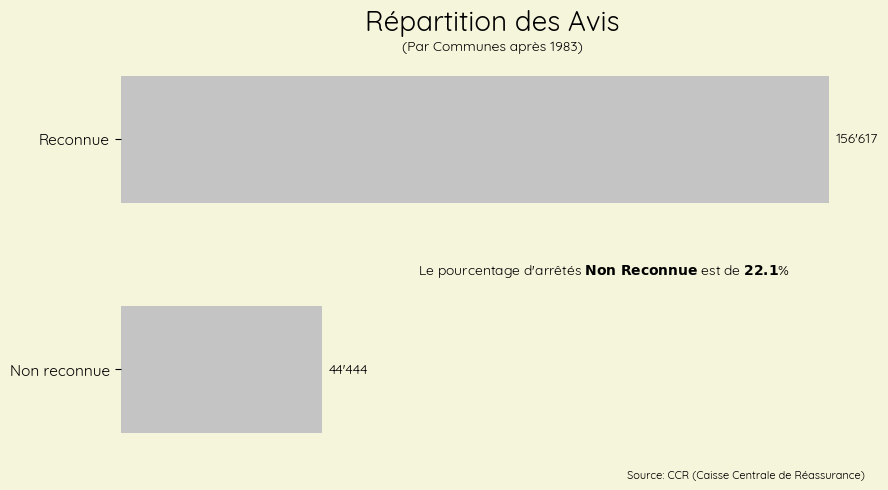

In [48]:
def bar_distribution(df, 
                     font=None,
                     figsize=(9, 5),
                     filter_year=1983,
                     color="#C4C4C4",
                     analysis="reconnaissance"):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing columns "dateArrete", "libelleAvis", "franchise", and "nomCommune".
    font : str or matplotlib.font_manager.FontProperties, optional
        Font to use for text elements in the plot. If None, uses the default font.
    figsize : tuple of int, default=(9, 5)
        Figure size in inches (width, height).
    filter_year : int, default=1983
        Only include decrees from years after this value.
    color : str, default="#C4C4C4"
        Color of the bars in the plot.
    analysis : str, default="reconnaissance"
        Type of analysis to perform. Must be either "reconnaissance" or "franchise".
        - "reconnaissance": Plots the distribution of "libelleAvis".
        - "franchise": Plots the distribution of "franchise" for decrees with "Reconnue" status.

    Returns
    -------
    matplotlib.figure.Figure
        The generated figure object containing the bar plot.
    """
    df_plot = df.copy()
    df_plot = df_plot[df_plot["dateArrete"].dt.year > filter_year]

    if analysis == 'franchise':
        selected_col = "franchise"
        df_plot = df_plot[
            df_plot["libelleAvis"] == "Reconnue"
        ]
        title = "Répartition des Franchises"
    else:
        selected_col = "libelleAvis"
        title = "Répartition des Avis"

    df_plot = (
        df_plot.groupby(selected_col).count().sort_values(by="nomCommune")
    )

    fig, ax = plt.subplots(figsize=figsize)
    bars = plt.barh(
        df_plot.index, df_plot["nomCommune"], color=color, height=0.55
    )

    plt.title(title, font=font, fontsize=20, color="black", pad=20)
    plt.text(
        0.5,
        1.02,
        f"(Par Communes après {filter_year})",
        font=font,
        fontsize=10,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )  # subtitle

    plt.ylabel("")

    # Removing axis
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)

    # Add labels to each bar
    for bar in bars:
        width = bar.get_width()
        plt.gca().text(
            width + 1500,
            bar.get_y() + bar.get_height() / 2.0,
            f"{int(width):,}".replace(",", "'"),
            ha="left",
            va="center",
            color="black",
            font=font,
        )

    plt.yticks(font=font, fontsize=11)

    if analysis == "reconnaissance":
        percent_nr = (
            df_plot["nomCommune"].loc["Non reconnue"]
            / df_plot["nomCommune"].sum()
        )

        plt.text(
            0.65,
            0.45,
            f"Le pourcentage d'arrêtés $\mathbf{{Non\ Reconnue}}$ est de $\mathbf{{{(percent_nr * 100).round(1)}}}$%",
            font=font,
            fontsize=10,
            color="black",
            ha="center",
            transform=ax.transAxes,
        )

    plt.text(
            1,
            -0.075,
            source_text,
            ha="right",
            va="bottom",
            transform=ax.transAxes,
            fontsize=8,
            color="black",
            font=font,
            )
    plt.grid(False)
    plt.tight_layout()
    return fig

bar_distribution(ccr_details_df, filter_year=1983);

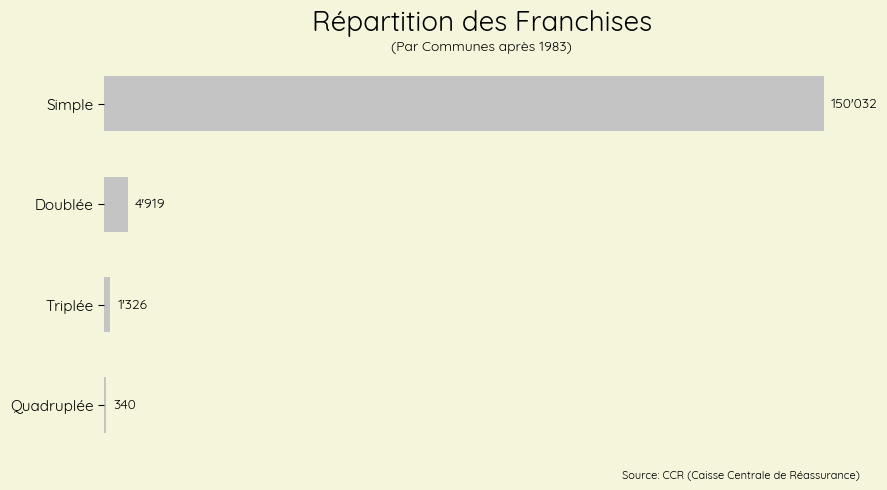

In [51]:
bar_distribution(ccr_details_df, filter_year=1983, analysis="franchise");

### _PROGRESSION DE LA NON RECONNAISSANCE & FRANCHISES_

In [53]:
def prepare_data_line_chart(df, 
                            group_freq="YE",
                            target_col="libelleAvis",
                            end_date="2025-12-31", 
                            remove_simple=True):
    df_plot = df.copy()
    if target_col == "franchise":
        df_plot = df_plot[(df_plot["libelleAvis"] != "Non reconnue") & \
                          ((df_plot[target_col] != "Simple") if remove_simple else True)]

    df_plot = (
        df_plot.groupby(
            [pd.Grouper(key="dateArrete", freq=group_freq), target_col]
        )
        .size()
        .reset_index(name="count")
    )

    df_plot = df_plot[
        df_plot["dateArrete"].dt.year <= 2026
    ]

    df_plot = df_plot.pivot(index="dateArrete", columns=target_col, values="count").fillna(0)
    df_plot = df_plot.loc[:end_date]

    return df_plot

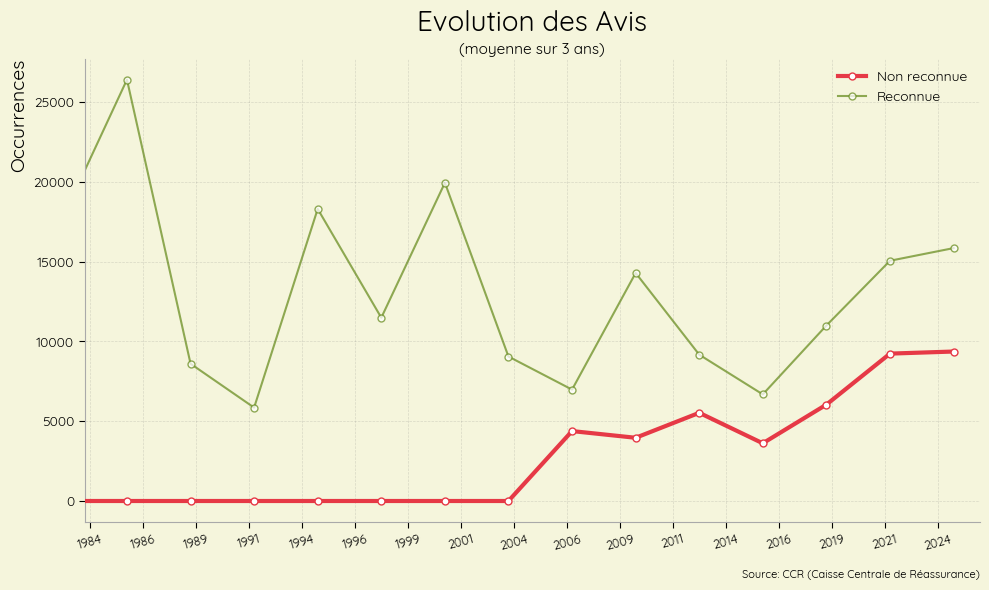

In [64]:
def line_chart_global(df, 
                      font=None,
                      group_freq="YE",
                      target_col="libelleAvis",
                      start_date="1984",
                      end_date="2025-12-31",
                      figsize=(10, 6)):

    annee = int(group_freq.split("YE")[0] or 1)
    df_plot = prepare_data_line_chart(df, 
                                      group_freq=group_freq,
                                      target_col=target_col,
                                      end_date=end_date)
    if target_col == "libelleAvis":
        title = "Evolution des Avis"
        subtitle = f"(moyenne sur {annee} ans)"
    else:
        title = "Evolution des Franchises"
        subtitle = f"(exclus franchise simple, moyenne sur {annee} ans)"

    fig, ax = plt.subplots(figsize=figsize)

    for column in df_plot.columns:
        if target_col == "libelleAvis":
                if "Non reconnue" in column:
                    color = "#e63946"
                    linewidth = 3
                    zorder = 5

                    ax.plot(
                        df_plot.index,
                        df_plot[column],
                        label=column,
                        color=color,
                        linewidth=linewidth,
                        marker="o",
                        linestyle="-",
                        ms=5,
                        markerfacecolor="white",
                        markeredgewidth=1,
                        zorder=zorder,
                    )
                else:
                    ax.plot(
                        df_plot.index,
                        df_plot[column],
                        label=column,
                        marker="o",
                        linestyle="-",
                        ms=5,
                        markerfacecolor="white",
                        markeredgewidth=1,
                        alpha=0.75,
                        zorder=1,
                    )
        else:
             ax.plot(
                    df_plot.index,
                    df_plot[column],
                    label=column,
                    marker="o",
                    linestyle="-",
                    ms=5,
                    markerfacecolor="white",
                    markeredgewidth=1,
                    alpha=1,
                    zorder=1,
                )

    plt.title(title, font=font, fontsize=20, color="black", pad=20)
    plt.text(
        0.5,
        1.01,
        subtitle,
        font=font,
        fontsize=11,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )

    plt.xlabel("")
    plt.ylabel("Occurrences", font=font, fontsize=14, color="black")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=30))

    plt.xticks(font=font, rotation=15, fontsize=9)
    plt.yticks(font=font, fontsize=10)

    plt.xlim([pd.to_datetime(start_date), pd.to_datetime("2026-03-31")])

    ax.legend(prop=font, loc="upper right", 
              frameon=False, labelcolor="black")

    handles, labels = ax.get_legend_handles_labels()

    if target_col == "franchise":
        desired_order = ["Doublée", "Triplée", "Quadruplée"]

        order_map = dict(zip(labels, handles))
        new_handles = [order_map[l] for l in desired_order if l in order_map]
        new_labels = [l for l in desired_order if l in order_map]

        ax.legend(new_handles, new_labels, prop=font, loc="upper left", 
                  frameon=False, labelcolor="black")

    plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    plt.tight_layout()
    return fig

line_chart_global(ccr_details_df, group_freq="3YE");

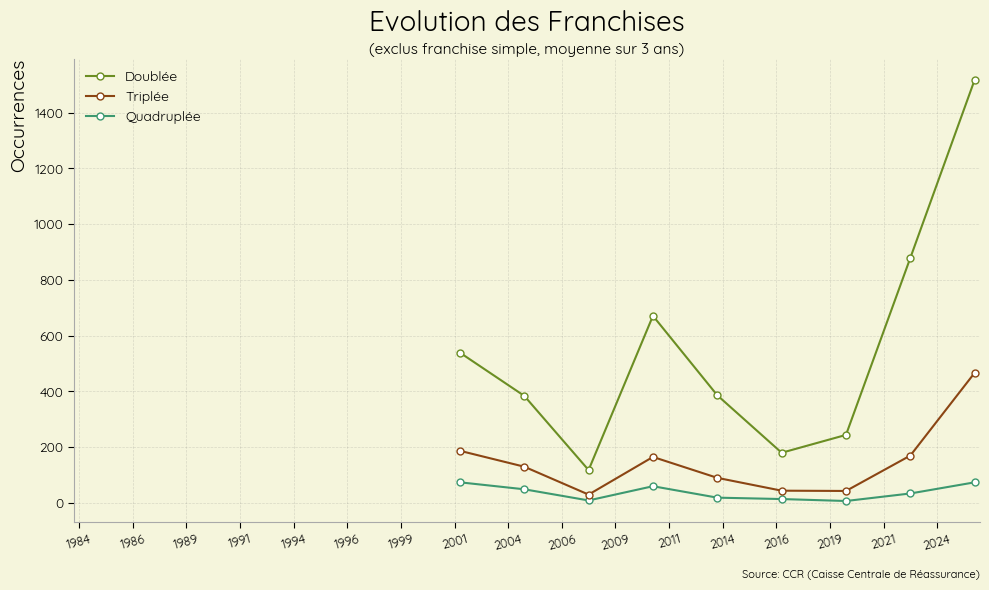

In [60]:
line_chart_global(ccr_details_df, group_freq="3YE", target_col="franchise");

### _PROGRESSION TAUX NON-RECONNAISSANCE_

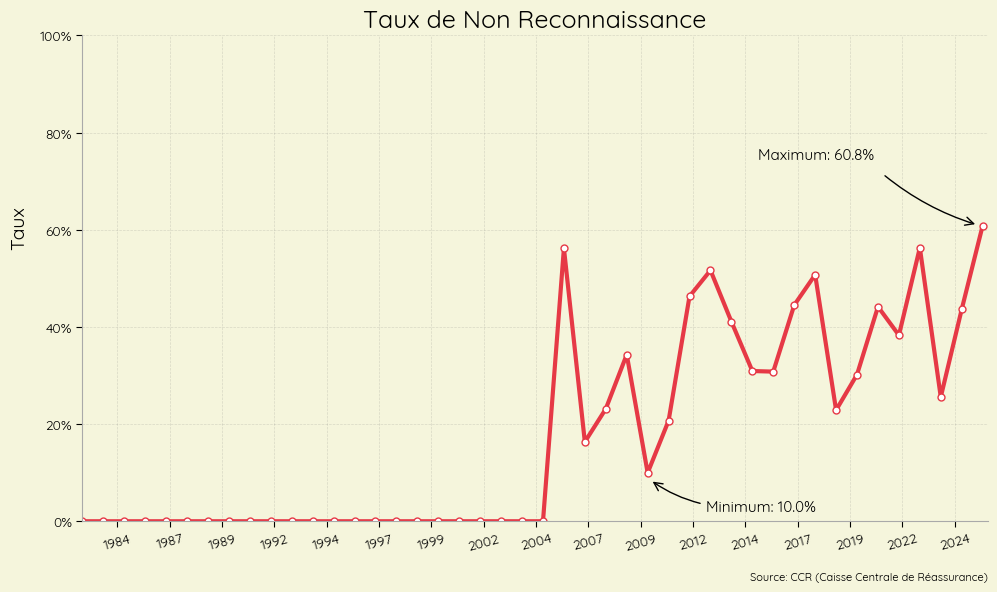

In [69]:
def add_arrow_indicators(ax, df, font=None, indicators_config=None):
    if indicators_config is None:
        indicators_config = {
            "Maximum": {
                "val": df.max(),
                "head": (0.975, 0.615),
                "tail": (0.88, 0.7),
                "radius": 0.1,
                "text_pos": (0.875, 0.74)
            },
            "Minimum": {
                "val": df[df > 0].min(),
                "head": (0.6475, 0.19),
                "tail": (0.7, 0.15),
                "radius": -0.1,
                "text_pos": (0.81, 0.015)
            }
        }

    for label, cfg in indicators_config.items():
        fig_arrow(
            head_position=cfg["head"],
            tail_position=cfg["tail"],
            radius=cfg["radius"],
            width=1, 
            color="black",
            fill_head=False, 
            mutation_scale=0.75, 
        )

        ax.text(
            cfg["text_pos"][0], 
            cfg["text_pos"][1],
            f"{label}: {cfg['val']*100:.1f}%",
            ha="right", 
            va="bottom", 
            transform=ax.transAxes,
            fontsize=11, 
            color="black", 
            fontproperties=font
        )



def line_chart_taux(df, font=None, 
                    group_freq="YE", 
                    target_col="libelleAvis", 
                    end_date="2025-12-31", 
                    indicators_positions=None):

    df_plot = df.copy()
    if target_col == "libelleAvis":
        select_cols = ["Non reconnue", "Reconnue"]
        title="Taux de Non Reconnaissance"
    else:
        df_plot['franchise'] = df_plot["franchise"].replace(
                                                          {"Doublée":"Doublée ou plus",
                                                           "Triplée":"Doublée ou plus",
                                                           "Quadruplée":"Doublée ou plus"})
        select_cols = ["Doublée ou plus", "Simple"]
        title="Taux de Franchises 'Doublée ou plus'"

    df_plot = prepare_data_line_chart(
        df_plot, group_freq=group_freq, target_col=target_col, end_date=end_date, remove_simple=False
    )

    total = df_plot[select_cols[0]] + df_plot[select_cols[1]]
    df_plot = df_plot[select_cols[0]] / total.replace(0, 1)
    df_plot = df_plot.loc[:end_date]

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F5F5DC')

    ax.plot(
        df_plot.index, df_plot,
        color="#e63946", linewidth=3, marker="o", ms=5,
        markerfacecolor="white", markeredgewidth=1
    )

    if target_col == "libelleAvis":
        add_arrow_indicators(ax, df_plot, font=font, indicators_config=indicators_positions)

    ax.set_title(title, fontproperties=font, fontsize=18, color="black")
    ax.set_ylabel("Taux", fontproperties=font, fontsize=14, color="black")
    ax.yaxis.set_label_coords(-0.06, 0.65)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=30))
    plt.xticks(rotation=15, fontsize=9, fontproperties=font)
    ax.set_xlim([df_plot.index.min(), pd.to_datetime("2026-03-31")])

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0.0, 1.0)
    plt.yticks(fontsize=10, fontproperties=font)

    ax.legend(prop=font, loc="upper right", frameon=False)
    ax.text(
        1, -0.125, source_text, ha="right", va="bottom", 
        transform=ax.transAxes, fontsize=8, color="black", fontproperties=font
    )

    # Clean Spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig

line_chart_taux(ccr_details_df);